# Notebook 2/3 — Training

**Pipeline**: Heterogeneous RGAT for Source-Code Graph Link Prediction

This notebook:
1. Loads preprocessed artifacts from `01_preprocessing.ipynb`
2. Builds the HeteroRGATEncoder (GATv2Conv in HeteroConv) + dot-product decoder
3. Trains via masked link prediction with BCEWithLogitsLoss
4. Tracks per-relation metrics (AUC, AP, accuracy) with early stopping
5. Visualizes training curves
6. Saves the trained model checkpoint

**Prerequisites**: Run `01_preprocessing.ipynb` first to generate artifacts.

## 1. Imports & Setup

In [46]:
%pip install torch_geometric sentence-transformers igraph leidenalg --quiet

In [47]:
# ── Colab Setup ──────────────────────────────────────────────────────
import shutil, zipfile
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

DRIVE_DIR = Path("/content/drive/MyDrive/MSAAI/capstone")
PROJECT_ROOT = Path("/content/rgat_project")
PROJECT_ROOT.mkdir(exist_ok=True)

# Always re-extract source code to pick up any changes
zip_src = DRIVE_DIR / "rgat_source.zip"
# Remove old source to ensure fresh extraction
for pkg in ["rgat", "graph_builder"]:
    old = PROJECT_ROOT / pkg
    if old.exists():
        shutil.rmtree(old)
with zipfile.ZipFile(zip_src, "r") as zf:
    zf.extractall(PROJECT_ROOT)
print("✓ Source code extracted (fresh)")

for d in ["artifacts", "cache", "checkpoints"]:
    (PROJECT_ROOT / d).mkdir(exist_ok=True)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Source code extracted (fresh)
PROJECT_ROOT = /content/rgat_project


In [48]:
import sys, time, warnings, importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

# PROJECT_ROOT set in Colab setup cell
sys.path.insert(0, str(PROJECT_ROOT))

# Force-reload source modules in case the kernel cached an older version
for mod_name in list(sys.modules):
    if mod_name.startswith("rgat"):
        del sys.modules[mod_name]

from rgat.config import RGATConfig
from rgat.model import HeteroRGATEncoder, LinkPredictor
from rgat.training import train, evaluate_link_prediction

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted")

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
print(f"PyTorch {torch.__version__}")
print(f"Artifacts: {ARTIFACTS_DIR}")

PyTorch 2.10.0+cu128
Artifacts: /content/rgat_project/artifacts


## 2. Load Preprocessed Artifacts

Load train/val HeteroData, node index, and config from the artifacts directory.

In [51]:
t0 = time.perf_counter()

# Load config
config_dict = torch.load(ARTIFACTS_DIR / "config.pt", weights_only=False)
config = RGATConfig(**config_dict)

# Override with improved hyperparameters
config.num_heads = 8
config.diversity_loss_weight = 1.0
config.epochs = 200
config.patience = 25

config.resolve_device()

# Load preprocessed graph data
train_data = torch.load(ARTIFACTS_DIR / "train_data.pt", weights_only=False)
val_data   = torch.load(ARTIFACTS_DIR / "val_data.pt",   weights_only=False)

# Load node index
import json
with open(ARTIFACTS_DIR / "node_index.json") as f:
    node_index = json.load(f)

load_time = time.perf_counter() - t0

print(f"Loaded in {load_time:.1f}s")
print(f"Device: {config.device}")
print(f"num_heads={config.num_heads}, diversity_loss_weight={config.diversity_loss_weight}")
print(f"epochs={config.epochs}, patience={config.patience}")
print(f"Train edge types: {len(train_data.edge_types)}")
print(f"Val edge types  : {len(val_data.edge_types)}")
print(f"Node index types: {list(node_index.keys())}")

Loaded in 0.5s
Device: cuda
num_heads=8, diversity_loss_weight=1.0
epochs=200, patience=25
Train edge types: 17
Val edge types  : 17
Node index types: ['class', 'function', 'module', 'repo']


## 3. Build Model

**Architecture**:
- **HeteroRGATEncoder**: Per-type input projection → 2 stacked HeteroConv layers (each with a GATv2Conv per edge type, 4 heads) → LayerNorm + residual
- **LinkPredictor**: Dot-product decoder → scalar logits for BCEWithLogitsLoss
- Leiden community embedding: `nn.Embedding(num_communities, 16)`

In [52]:
all_edge_types = list(train_data.edge_types)
all_node_types = list(config.input_dims.keys())

encoder = HeteroRGATEncoder(
    node_types=all_node_types,
    edge_types=all_edge_types,
    scalar_dims=config.scalar_dims,
    sentence_dim=config.sentence_dim,
    leiden_embed_dim=config.leiden_embed_dim,
    num_leiden_ids=config.num_leiden_ids,
    hidden_dim=config.hidden_dim,
    num_heads=config.num_heads,
    num_layers=config.num_layers,
    dropout=config.dropout,
)
predictor = LinkPredictor()

n_enc = sum(p.numel() for p in encoder.parameters())
n_pred = sum(p.numel() for p in predictor.parameters())

print(f"Encoder parameters : {n_enc:,}")
print(f"Predictor parameters: {n_pred:,}")
print(f"Total parameters   : {n_enc + n_pred:,}")
print(f"\nNode types ({len(all_node_types)}): {all_node_types}")
print(f"Edge types ({len(all_edge_types)}): {len(all_edge_types)} (incl. reverse)")
print(f"\nHyperparameters:")
print(f"  hidden_dim={config.hidden_dim}, num_heads={config.num_heads}, "
      f"num_layers={config.num_layers}, dropout={config.dropout}")
print(f"  lr={config.lr}, weight_decay={config.weight_decay}, "
      f"patience={config.patience}, val_every={config.val_every}")

Encoder parameters : 2,787,248
Predictor parameters: 0
Total parameters   : 2,787,248

Node types (4): ['class', 'function', 'module', 'repo']
Edge types (17): 17 (incl. reverse)

Hyperparameters:
  hidden_dim=128, num_heads=8, num_layers=2, dropout=0.2
  lr=0.001, weight_decay=0.0001, patience=25, val_every=5


## 4. Training

Full-batch training with masked link prediction on the supervised edge types (CALLS, INHERITS, IMPORTS_MODULE).

Metrics reported per-relation every `val_every` epochs:
- **Loss**: BCEWithLogitsLoss
- **Accuracy**: sigmoid ≥ 0.5 threshold
- **ROC-AUC**: ranking quality metric
- **Average Precision**: precision-recall summary

Early stopping on aggregate validation AUC.

In [53]:
%%time

# Override checkpoint dir to use project root
config.checkpoint_dir = str(PROJECT_ROOT / "checkpoints")

history = train(encoder, predictor, train_data, val_data, config)

print(f"\nTraining complete.")
print(f"Epochs run: {len(history['epoch'])}")
print(f"Best val AUC: {max(history['val_auc']):.4f}")

[training] Supervised triplets: [('class', 'INHERITS', 'class'), ('module', 'IMPORTS_MODULE', 'module'), ('function', 'CALLS', 'function'), ('function', 'CALLS', 'class')]
[training] Device: cuda
  Epoch    1/200 | train_loss=2.7939 | val_loss=2.8218 | val_AUC=0.5269 | val_AP=0.5641 | 8.6s
    (class, INHERITS, class): loss=0.6625  acc=0.5593  AUC=0.7132  AP=0.7177  n=2,430
    (module, IMPORTS_MODULE, module): loss=0.8238  acc=0.5000  AUC=0.1816  AP=0.3403  n=11,630
    (function, CALLS, function): loss=0.6727  acc=0.5875  AUC=0.6825  AP=0.6478  n=17,556
    (function, CALLS, class): loss=0.6628  acc=0.6858  AUC=0.8081  AP=0.8206  n=2,960
    [checkpoint] Saved best model to /content/rgat_project/checkpoints/best_model.pt
  Epoch    5/200 | train_loss=2.6052 | val_loss=2.7354 | val_AUC=0.5752 | val_AP=0.6052 | 0.6s
    (class, INHERITS, class): loss=0.6453  acc=0.6346  AUC=0.7448  AP=0.7408  n=2,430
    (module, IMPORTS_MODULE, module): loss=0.8082  acc=0.5000  AUC=0.2371  AP=0.3596  

In [54]:
# Quick summary of training results
print(f"Total epochs trained: {len(history['epoch'])}")
print(f"Best val AUC: {max(history['val_auc']):.4f}")
print(f"Best val AP:  {max(history['val_ap']):.4f}")
best_auc_idx = history['val_auc'].index(max(history['val_auc']))
print(f"Best AUC at val step index: {best_auc_idx}")
print(f"\nLast 5 val AUC: {history['val_auc'][-5:]}")
print(f"Last 5 val AP:  {history['val_ap'][-5:]}")
print(f"Last 5 train loss: {[f'{x:.4f}' for x in history['train_loss'][-5:]]}")

Total epochs trained: 200
Best val AUC: 0.7502
Best val AP:  0.7724
Best AUC at val step index: 36

Last 5 val AUC: [0.7502018015286034, 0.7465669745126206, 0.7390916753301513, 0.7365462720334509, 0.7374642261211319]
Last 5 val AP:  [0.7723849436771599, 0.7708544796891931, 0.7656218998861616, 0.7637242382908156, 0.7642221489184484]
Last 5 train loss: ['3.0951', '3.0974', '3.0908', '3.0938', '3.0923']


## 5. Training Curves

Visualize loss, AUC, and AP over training epochs.

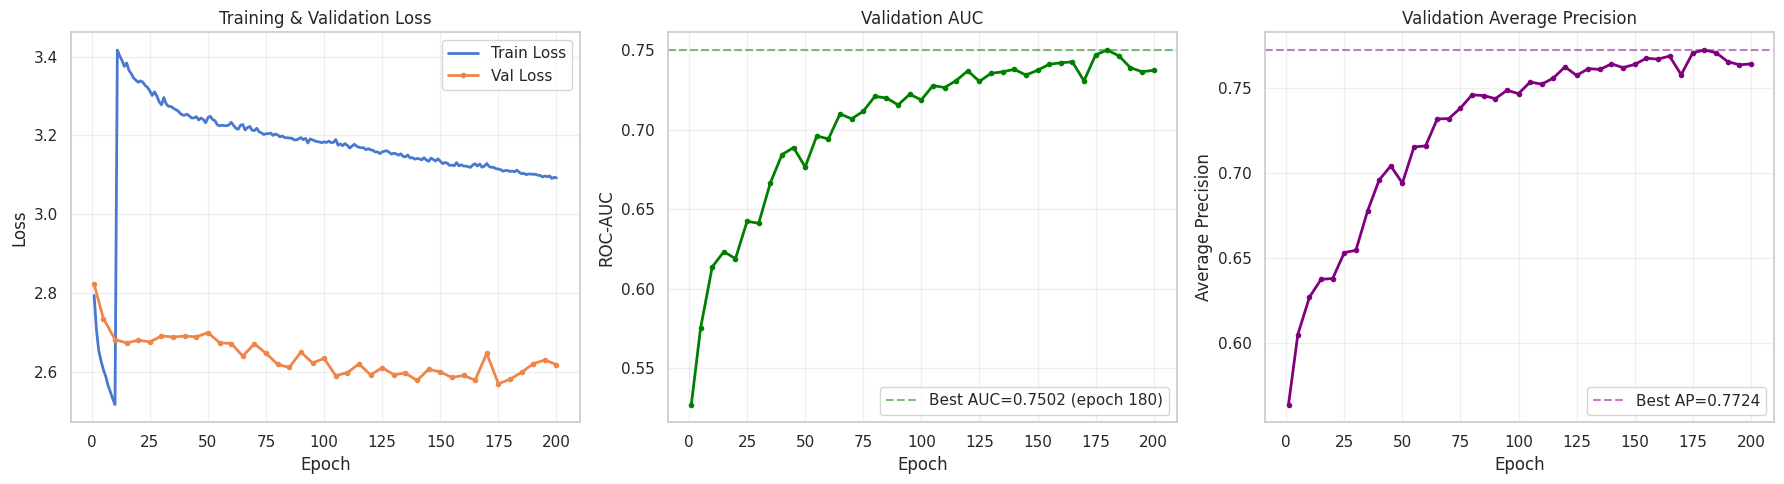

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Loss curve ──
ax = axes[0]
ax.plot(history["epoch"], history["train_loss"], label="Train Loss", linewidth=2)
# val_loss is only recorded at val_every intervals; align x-axis
val_epochs = [e for e in history["epoch"] if e == 1 or e % config.val_every == 0]
ax.plot(val_epochs[:len(history["val_loss"])], history["val_loss"],
        label="Val Loss", linewidth=2, marker="o", markersize=3)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# ── AUC curve ──
ax = axes[1]
ax.plot(val_epochs[:len(history["val_auc"])], history["val_auc"],
        color="green", linewidth=2, marker="o", markersize=3)
best_auc = max(history["val_auc"])
best_epoch = val_epochs[history["val_auc"].index(best_auc)]
ax.axhline(best_auc, color="green", linestyle="--", alpha=0.5,
           label=f"Best AUC={best_auc:.4f} (epoch {best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("ROC-AUC")
ax.set_title("Validation AUC")
ax.legend()
ax.grid(True, alpha=0.3)

# ── AP curve ──
ax = axes[2]
ax.plot(val_epochs[:len(history["val_ap"])], history["val_ap"],
        color="purple", linewidth=2, marker="o", markersize=3)
best_ap = max(history["val_ap"])
ax.axhline(best_ap, color="purple", linestyle="--", alpha=0.5,
           label=f"Best AP={best_ap:.4f}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average Precision")
ax.set_title("Validation Average Precision")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Save Training Artifacts

Save training history and confirm checkpoint was written. The best model checkpoint is automatically saved during training via early stopping.

In [56]:
import os

# Save training history
torch.save(history, ARTIFACTS_DIR / "training_history.pt")
print(f"✓ Saved training_history.pt")

# Verify checkpoint exists
ckpt_path = PROJECT_ROOT / "checkpoints" / "best_model.pt"
if ckpt_path.exists():
    ckpt_size = os.path.getsize(ckpt_path) / 1e6
    print(f"✓ Best model checkpoint: {ckpt_path} ({ckpt_size:.1f} MB)")
else:
    print(f"⚠ Checkpoint not found at {ckpt_path}")

# Also save the encoder/predictor edge_types list for reconstruction
torch.save({
    "all_node_types": all_node_types,
    "all_edge_types": all_edge_types,
}, ARTIFACTS_DIR / "model_metadata.pt")
print(f"✓ Saved model_metadata.pt")

print(f"\n→ Next: Open 03_evaluation.ipynb for final metrics and attention analysis.")

✓ Saved training_history.pt
✓ Best model checkpoint: /content/rgat_project/checkpoints/best_model.pt (11.3 MB)
✓ Saved model_metadata.pt

→ Next: Open 03_evaluation.ipynb for final metrics and attention analysis.
